In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'MS Gothic'

# 全8大学のデータ
data = [
    # 東京大学（国立・処置年2025）
    *[{'大学':'東京大学','年度':y,'志願者数':v,'処置群':1,'処置年':2025,'設置':'国立'} for y,v in zip(range(2015,2026),[9444,9278,9534,9675,9483,9259,9089,9507,9306,9688,8421])],
    # 東京工業大学（国立・処置年2019）
    *[{'大学':'東京工業大学','年度':y,'志願者数':v,'処置群':1,'処置年':2019,'設置':'国立'} for y,v in zip(range(2015,2024),[3803,3892,4167,4229,4222,3790,3638,3802,4167])],
    # 一橋大学（国立・処置年2020）
    *[{'大学':'一橋大学','年度':y,'志願者数':v,'処置群':1,'処置年':2020,'設置':'国立'} for y,v in zip(range(2015,2026),[4121,4172,4484,4136,3810,3565,3600,3832,4380,4404,4568])],
    # 東京藝術大学（国立・処置年2019）
    *[{'大学':'東京藝術大学','年度':y,'志願者数':v,'処置群':1,'処置年':2019,'設置':'国立'} for y,v in zip(range(2015,2025),[2736,2915,2937,2934,2824,2793,2523,2693,2861,2929])],
    # 京都大学（国立・対照群）
    *[{'大学':'京都大学','年度':y,'志願者数':v,'処置群':0,'処置年':None,'設置':'国立'} for y,v in zip(range(2016,2026),[8029,7875,7861,7511,7347,7045,7210,7417,7800,8077])],
    # 名古屋大学（国立・対照群）
    *[{'大学':'名古屋大学','年度':y,'志願者数':v,'処置群':0,'処置年':None,'設置':'国立'} for y,v in zip(range(2016,2025),[4719,4723,4752,4736,4422,4581,4339,4258,4359])],
    # 早稲田大学（私立・処置年2024）
    *[{'大学':'早稲田大学','年度':y,'志願者数':v,'処置群':1,'処置年':2024,'設置':'私立'} for y,v in zip(range(2015,2026),[103494,108039,114983,117209,111338,104576,91659,93843,90879,89420,95938])],
    # 慶應義塾大学（私立・処置年2023）
    *[{'大学':'慶應義塾大学','年度':y,'志願者数':v,'処置群':1,'処置年':2023,'設置':'私立'} for y,v in zip(range(2015,2026),[43352,44797,44845,43301,41875,38454,36681,37894,37411,37600,40132])],
    # 九州大学（国立・対照群・前期計）
    *[{'大学':'九州大学','年度':y,'志願者数':v,'処置群':0,'処置年':None,'設置':'国立'} for y,v in zip(range(2016,2026),[5095,5190,5246,5239,5014,5175,5143,5067,5107,5056])],
    # 明治大学（私立・処置年2023）
    *[{'大学':'明治大学','年度':y,'志願者数':v,'処置群':1,'処置年':2023,'設置':'私立'} for y,v in zip(range(2016,2026),[60374,60701,63416,58257,55637,55209,56742,59543,58551,60836])],
]

df = pd.DataFrame(data)
df['log_志願者数'] = np.log(df['志願者数'])

def make_post(row):
    if row['処置群'] == 0 or pd.isna(row['処置年']):
        return 0
    return 1 if row['年度'] >= row['処置年'] else 0

df['post'] = df.apply(make_post, axis=1)
df['treated_post'] = df['処置群'] * df['post']

print(f"大学数: {df['大学'].nunique()}, 総観測数: {len(df)}")
print(df.groupby(['大学','処置群'])['年度'].agg(['min','max']))

大学数: 10, 総観測数: 102
             min   max
大学     処置群            
一橋大学   1    2015  2025
九州大学   0    2016  2025
京都大学   0    2016  2025
名古屋大学  0    2016  2024
慶應義塾大学 1    2015  2025
早稲田大学  1    2015  2025
明治大学   1    2016  2025
東京大学   1    2015  2025
東京工業大学 1    2015  2023
東京藝術大学 1    2015  2024


In [7]:
# 国立大学のみで分析
df_nat = df[df['設置'] == '国立'].copy()

# 大学固定効果・年度固定効果付きDiD
model_nat = smf.ols(
    'log_志願者数 ~ treated_post + C(大学) + C(年度)',
    data=df_nat
).fit(cov_type='HC1')  # 不均一分散ロバスト標準誤差

print("=== 国立大学 DiD推定結果 ===")
print(f"treated_post係数: {model_nat.params['treated_post']:.4f}")
print(f"標準誤差:         {model_nat.bse['treated_post']:.4f}")
print(f"t値:              {model_nat.tvalues['treated_post']:.3f}")
print(f"p値:              {model_nat.pvalues['treated_post']:.3f}")
print(f"R²:               {model_nat.rsquared:.3f}")
print(f"\n解釈: 学費値上げにより志願者数が約{(np.exp(model_nat.params['treated_post'])-1)*100:.1f}%変化")

=== 国立大学 DiD推定結果 ===
treated_post係数: -0.0132
標準誤差:         0.0260
t値:              -0.509
p値:              0.611
R²:               0.990

解釈: 学費値上げにより志願者数が約-1.3%変化


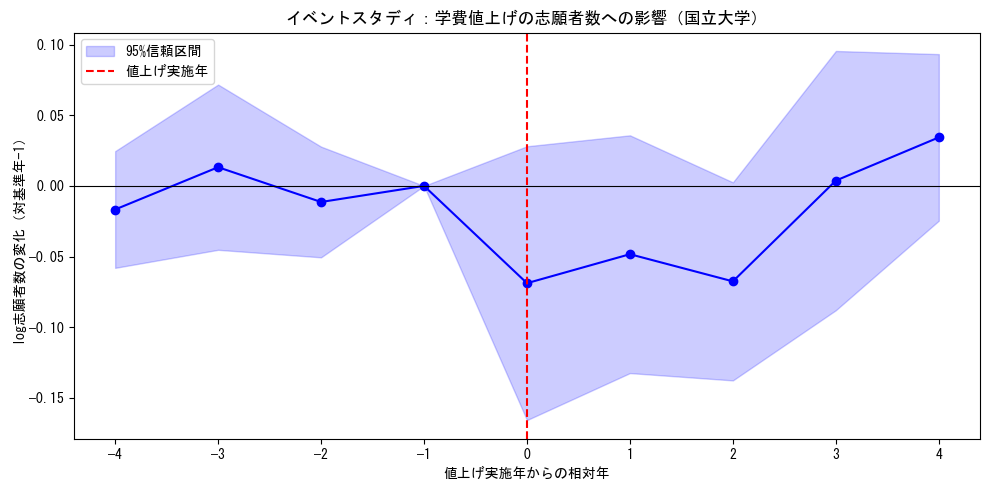

 rel_year      coef       se
       -4 -0.016711 0.021064
       -3  0.013214 0.029823
       -2 -0.011395 0.019979
       -1  0.000000 0.000000
        0 -0.068842 0.049417
        1 -0.048340 0.042909
        2 -0.067559 0.035749
        3  0.003743 0.046788
        4  0.034308 0.030063


In [8]:
# 相対年を計算
def relative_year(row):
    if row['処置群'] == 0 or pd.isna(row['処置年']):
        return None
    return row['年度'] - int(row['処置年'])

df_nat['rel_year'] = df_nat.apply(relative_year, axis=1)

# 変数名のマイナスをmに変更（例：-4 → m4、+2 → p2）
for k in range(-4, 5):
    if k == -1:
        continue
    vname = f'treat_yr_m{abs(k)}' if k < 0 else f'treat_yr_p{k}'
    df_nat[vname] = ((df_nat['処置群'] == 1) & (df_nat['rel_year'] == k)).astype(int)

yr_vars = []
for k in range(-4, 5):
    if k == -1:
        continue
    vname = f'treat_yr_m{abs(k)}' if k < 0 else f'treat_yr_p{k}'
    yr_vars.append(vname)

formula = 'log_志願者数 ~ ' + ' + '.join(yr_vars) + ' + C(大学) + C(年度)'
model_es = smf.ols(formula, data=df_nat).fit(cov_type='HC1')

# 結果整理
coefs = []
for k in range(-4, 5):
    if k == -1:
        coefs.append({'rel_year': k, 'coef': 0, 'se': 0})
    else:
        vname = f'treat_yr_m{abs(k)}' if k < 0 else f'treat_yr_p{k}'
        if vname in model_es.params:
            coefs.append({'rel_year': k, 'coef': model_es.params[vname], 'se': model_es.bse[vname]})

res = pd.DataFrame(coefs)

# プロット
plt.figure(figsize=(10, 5))
plt.plot(res['rel_year'], res['coef'], marker='o', color='blue')
plt.fill_between(res['rel_year'],
    res['coef'] - 1.96 * res['se'],
    res['coef'] + 1.96 * res['se'],
    alpha=0.2, color='blue', label='95%信頼区間')
plt.axvline(x=0, color='red', linestyle='--', label='値上げ実施年')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xlabel('値上げ実施年からの相対年')
plt.ylabel('log志願者数の変化（対基準年-1）')
plt.title('イベントスタディ：学費値上げの志願者数への影響（国立大学）')
plt.legend()
plt.tight_layout()
plt.show()

print(res.to_string(index=False))